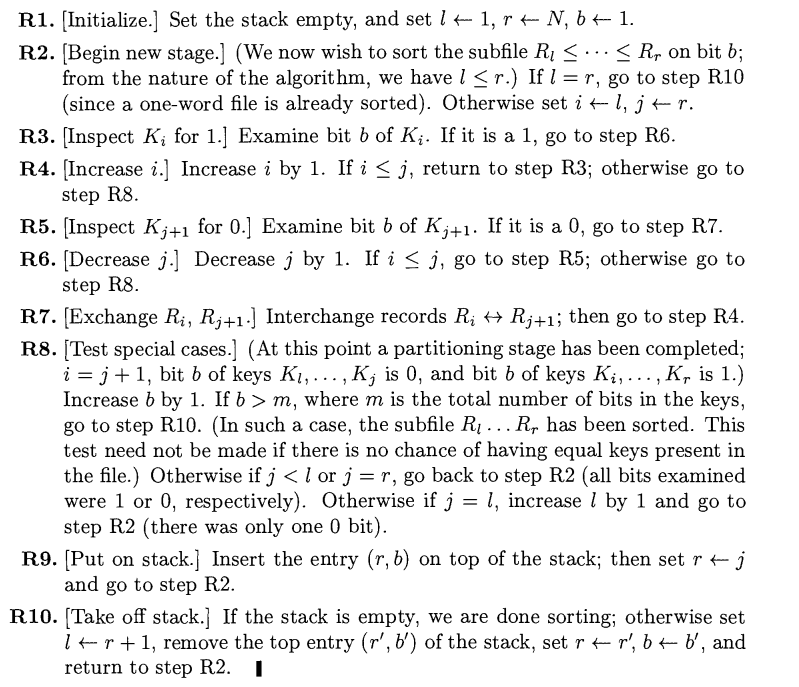

In [11]:
import pandas as pd


def radix_exchange_sort(arr):
    history = []

    # Calculate max bits once to align binary strings
    max_bits = max(arr).bit_length() if arr else 0

    def log_step(step_type, l, r, bit, i, j, current_arr):
        # Convert each number to a binary string like '0101'
        binary_repr = [format(x, f"0{max_bits}b") for x in current_arr]

        history.append(
            {
                "Step": step_type,
                "L": l,
                "R": r,
                "Bit": bit,
                "i": i,
                "j": j,
                "Array": list(current_arr),
                "Binary": binary_repr,
            }
        )

    if not arr:
        return arr

    # Find the most significant bit (MSB) for the largest number
    max_val = max(arr)
    bit_position = max_val.bit_length() - 1

    def _sort(left, right, bit):
        # Base case: no more bits to check or sub-array is too small
        if bit < 0 or left >= right:
            return

        i, j = left, right
        mask = 1 << bit

        log_step("Start Partition", left, right, bit, i, j, arr)

        while i <= j:
            # Move i right until we find a number with bit set to 1
            while i <= j and not (arr[i] & mask):
                i += 1
            # Move j left until we find a number with bit set to 0
            while i <= j and (arr[j] & mask):
                j -= 1

            # Swap elements to partition the array
            if i < j:
                arr[i], arr[j] = arr[j], arr[i]
                log_step("Swap", left, right, bit, i, j, arr)
                i += 1
                j -= 1

        log_step("End Partition", left, right, bit, i, j, arr)
        # Recursively sort the '0' partition and the '1' partition
        _sort(left, i - 1, bit - 1)
        _sort(i, right, bit - 1)

    _sort(0, len(arr) - 1, bit_position)
    return arr, pd.DataFrame(history)


# Example usage:
data = [3, 10, 15, 7, 8, 2, 4]
arr, hist = radix_exchange_sort(data)
display(arr, hist)

[2, 3, 4, 7, 8, 10, 15]

,Step,L,R,Bit,i,j,Array,Binary
0,Start Partition,0,6,3,0,6,"[3, 10, 15, 7, 8, 2, 4]","[0011, 1010, 1111, 0111, 1000, 0010, 0100]"
1,Swap,0,6,3,1,6,"[3, 4, 15, 7, 8, 2, 10]","[0011, 0100, 1111, 0111, 1000, 0010, 1010]"
2,Swap,0,6,3,2,5,"[3, 4, 2, 7, 8, 15, 10]","[0011, 0100, 0010, 0111, 1000, 1111, 1010]"
3,End Partition,0,6,3,4,3,"[3, 4, 2, 7, 8, 15, 10]","[0011, 0100, 0010, 0111, 1000, 1111, 1010]"
4,Start Partition,0,3,2,0,3,"[3, 4, 2, 7, 8, 15, 10]","[0011, 0100, 0010, 0111, 1000, 1111, 1010]"
5,Swap,0,3,2,1,2,"[3, 2, 4, 7, 8, 15, 10]","[0011, 0010, 0100, 0111, 1000, 1111, 1010]"
6,End Partition,0,3,2,2,1,"[3, 2, 4, 7, 8, 15, 10]","[0011, 0010, 0100, 0111, 1000, 1111, 1010]"
7,Start Partition,0,1,1,0,1,"[3, 2, 4, 7, 8, 15, 10]","[0011, 0010, 0100, 0111, 1000, 1111, 1010]"
8,End Partition,0,1,1,0,-1,"[3, 2, 4, 7, 8, 15, 10]","[0011, 0010, 0100, 0111, 1000, 1111, 1010]"
9,Start Partition,0,1,0,0,1,"[3, 2, 4, 7, 8, 15, 10]","[0011, 0010, 0100, 0111, 1000, 1111, 1010]"
